In [1]:
import spectfbcalc_lib as sfc
from matplotlib import pyplot as plt
import xarray as xr
import yaml
import glob
from climtools import climtools_lib as ctl
import numpy as np

No DISPLAY variable set. Switching to agg backend


In [2]:
import flox

In [6]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [10]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=4,
    memory="32GB",
    processes=4,
    walltime="02:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitfabi",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=4)  # This submits 4 SLURM jobs

# Connect client
client = Client(cluster)

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36475 instead
  warnings.warn(


In [5]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.100.192.102:41401/status,
Dashboard: http://10.100.192.102:41401/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.100.192.102:42901,Workers: 0
Dashboard: http://10.100.192.102:41401/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
import warnings
warnings.filterwarnings('once')

In [8]:
config_file = 'config_zelinka.yml'
control, experiment, kernel = sfc.preprocess_data(config_file, ker = 'SPECTRAL', wv_method_spectral='linear')

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: SPECTRAL

 -------> Loading control
PI already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
rsut loaded
wv_vmr_log loaded
rlut loaded
alb loaded
rsutcs loaded
ts loaded
ta loaded
tas loaded
rsdt loaded
rlutcs loaded
wv_vmr loaded
check vertical dimension
Rewriting vertical coordinates from Pa to hPa

 -------> Loading experiment
4x already remapped
Computing albedo from rsus and rsds
Converting hus to wv vmr
Creating Net TOA variables
rsut loaded
wv_vmr_log loaded
rlut loaded
alb loaded
rsutcs loaded
ts loaded
ta loaded
tas loaded
rsdt loaded
rlutcs loaded
wv_vmr loaded
check vertical dimension
Rewriting vertical coordinates from Pa to hPa

 -------> Computing climatology and anomalies

 ----------> Preprocessing complete for ece3_abrupt <------------



In [55]:
experiment.ds['hus']

<xarray.DataArray 'hus' (time: 1980, plev: 18, lat: 90, lon: 144)> Size: 2GB
dask.array<transpose, shape=(1980, 18, 90, 144), dtype=float32, chunksize=(120, 18, 30, 36), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * lat      (lat) int64 720B -89 -87 -85 -83 -81 -79 -77 ... 79 81 83 85 87 89
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
    height   float64 8B ...
Attributes:
    regrid_method:  bilinear

## Spectral calc
This runs in 43 min with 4x4 workers (32 Gb each group)

In [11]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_lin/'
anoms = sfc.calc_anoms(experiment, control, kernel, cart_out, use_strat_mask=False, save_pattern=False, force_recompute=False)

planck surf
Reading already computed anomaly from /perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_lin/dRt_planck-surf_global_clr.nc
planck atm
Reading already computed anomaly from /perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_lin/dRt_planck-atmo_global_clr.nc
albedo
Skipping albedo feedback for SPECTRAL kernels (not defined).
w-v
Processing clr
Before WV computation


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed lin part: <xarray.DataArray ()> Size: 8B
array(-48.86620915)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.33502182)
Attributes:
    regrid_method:  bilinear
Processing cld
Before WV computation


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 28.96 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computed lin part: <xarray.DataArray ()> Size: 8B
array(-47.45452257)
Attributes:
    regrid_method:  bilinear - <xarray.DataArray ()> Size: 8B
array(0.40269558)
Attributes:
    regrid_method:  bilinear


In [ ]:
# config_file = 'config_zelinka.yml'
# control, experiment, kernel = sfc.preprocess_data(config_file, ker = 'SPECTRAL', wv_method_spectral='log')

In [12]:
anoms = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [13]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_SPECTRAL_2/'
anoms_old = sfc.open_dRt(cart_out, names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [14]:
anoms_huang = sfc.open_dRt(cart_out + '../fb_HUANG_ok/', names = ['planck-surf', 'planck-atmo', 'lapse-rate', 'lw_water-vapor'])

In [17]:
%matplotlib inline

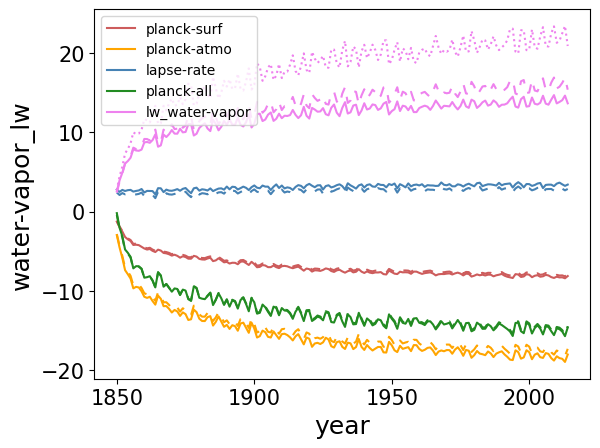

In [20]:
fig = plt.figure()
tip = 'clr'
fb_list = ['planck-surf', 'planck-atmo', 'lapse-rate', 'planck-all', 'lw_water-vapor']
colors = ['indianred', 'orange', 'steelblue', 'forestgreen', 'violet']
anoms_old[('clr', 'planck-all')] = anoms_old[('clr', 'planck-atmo')] + anoms_old[('clr', 'lapse-rate')]
anoms_huang[('clr', 'planck-all')] = anoms_huang[('clr', 'planck-atmo')] + anoms_huang[('clr', 'lapse-rate')]

for cos, col in zip(fb_list, colors):
    anoms_huang[(tip, cos)].plot(color = col, label = cos)
    (anoms_old[(tip, cos)].integrate('freq').groupby('time.year').mean()/-1000.).plot(color = col, ls = '--')
    if 'water' in cos:
        (anoms[(tip, cos)].integrate('freq').groupby('time.year').mean()/-1000.).plot(color = col, ls = ':')
plt.legend()

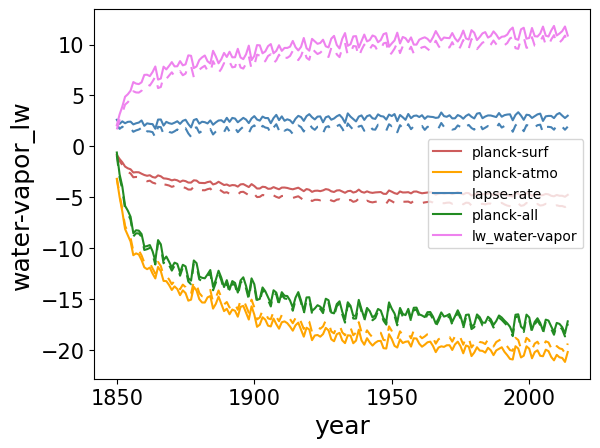

In [26]:
fig = plt.figure()
tip = 'cld'
fb_list = ['planck-surf', 'planck-atmo', 'lapse-rate', 'planck-all', 'lw_water-vapor']
colors = ['indianred', 'orange', 'steelblue', 'forestgreen', 'violet']
anoms[(tip, 'planck-all')] = anoms[(tip, 'planck-atmo')] + anoms[(tip, 'lapse-rate')]
anoms_huang[(tip, 'planck-all')] = anoms_huang[(tip, 'planck-atmo')] + anoms_huang[(tip, 'lapse-rate')]

for cos, col in zip(fb_list, colors):
    anoms_huang[(tip, cos)].plot(color = col, label = cos)
    (anoms[(tip, cos)].integrate('freq').groupby('time.year').mean()/-1000.).plot(color = col, ls = '--')
plt.legend()

In [17]:
anoms_huang

{('clr',
  'planck-surf'): <xarray.DataArray 'planck-surf' (year: 165)> Size: 660B
 [165 values with dtype=float32]
 Coordinates:
   * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
 Attributes:
     regrid_method:  bilinear
     units:          W/m2/K
     longname:       ts kernel at toa in clear sky,
 ('clr',
  'planck-atmo'): <xarray.DataArray 'planck-atmo' (year: 165)> Size: 660B
 [165 values with dtype=float32]
 Coordinates:
   * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
 Attributes:
     regrid_method:  bilinear
     longname:       t kernel at TOA in clear sky
     units:          W/m2/K/100mb,
 ('clr',
  'lapse-rate'): <xarray.DataArray 'lapse-rate' (year: 165)> Size: 660B
 [165 values with dtype=float32]
 Coordinates:
   * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2011 2012 2013 2014
 Attributes:
     regrid_method:  bilinear
     longname:       t kernel at TOA in clear sky
     units:          W/m2/K/

In [14]:
%matplotlib inline

In [22]:
fb_list_1 = ['planck-surf', 'planck-all', 'lw_water-vapor']
anoms[('clr', 'all')] = 0.*anoms[('clr', fb_list[0])]
for cos in fb_list_1:
    anoms[('clr', 'all')] += anoms[('clr', cos)]

KeyError: ('clr', 'all')

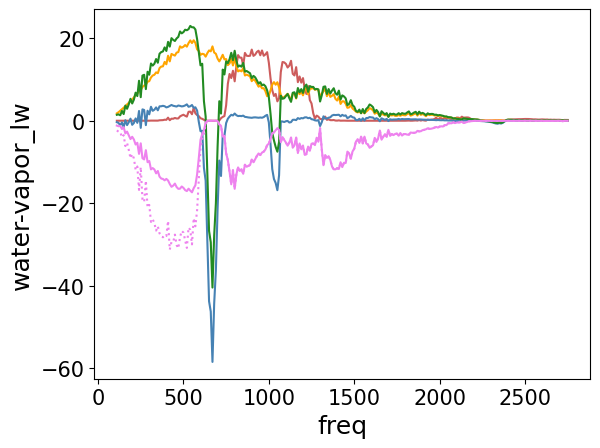

In [21]:
plt.figure()
for cos, col in zip(fb_list, colors + ['violet']):
    anoms_old[('clr', cos)].mean('time').plot(color = col, label = cos)
    if 'water' in cos:
        anoms[(tip, cos)].mean('time').plot(color = col, ls = ':')

anoms_old[('clr', 'all')].mean('time').plot(color = 'black', label = 'all')
plt.ylabel('dR (W/m2/cm-1)')

plt.legend()

In [9]:
coso = ctl.global_mean(kernel.kernel[('clr', 'wv_lw_log')].mean('month'))

In [10]:
coso.load()

<xarray.DataArray 'wv_jac' (plev: 18, freq: 265)> Size: 38kB
array([[ 1.69282298e-02,  1.88190430e-02,  5.04775941e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.63000219e-02,  5.32416634e-02,  1.25070571e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.87816892e-02,  3.29370548e-02,  8.22380878e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [-1.38862293e-05, -8.98120878e-06,  6.63358820e-07, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 2.52753993e-06,  2.94730271e-06,  1.59977875e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.77153059e-06,  2.05572943e-06,  1.11536688e-06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(18, 265))
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * freq     (freq) float64 2kB 110.0 120.0 130.0 ... 2.73e+03 2.74e+03 2.75e+03

1.0 0.004535099590013608 -0.00571956520291996 0.09522672398509445
0
161
10.0 0.009172359028040308 -0.006931748536673622 0.2362016770993064
0
161
20.0 0.004242129623884037 -0.03623899258681593 0.1344150100244366
0
161
30.0 0.0008546564840433612 -0.05906048793763278 0.10964171432739012
0
161
50.0 -0.004182170269287868 -0.05135793609962806 0.05252862784050185
0
161
70.0 -0.014745218014769653 -0.21023405101512027 0.0
0
161
100.0 -0.029125981543447067 -0.44460096440894614 0.0
0
161
150.0 -0.08375317928662046 -1.189516097942545 0.0
0
161
200.0 -0.18324913656114336 -2.014699457685529 0.0
0
161
250.0 -0.25753551428305016 -2.504795716308298 0.0
0
161
300.0 -0.37822785264715125 -3.6227960984118424 0.0
0
161
400.0 -0.6958254521993196 -6.647688369035722 0.0
0
161
500.0 -0.5536063742547305 -6.377005940874385 0.0
0
161
600.0 -0.35559039324140773 -6.036425725333955 0.0
0
161
700.0 -0.22369326674179166 -5.448678198448833 0.0
0
161
850.0 -0.15302035893439106 -4.416643739901625 6.633588203383697e-07
0
1

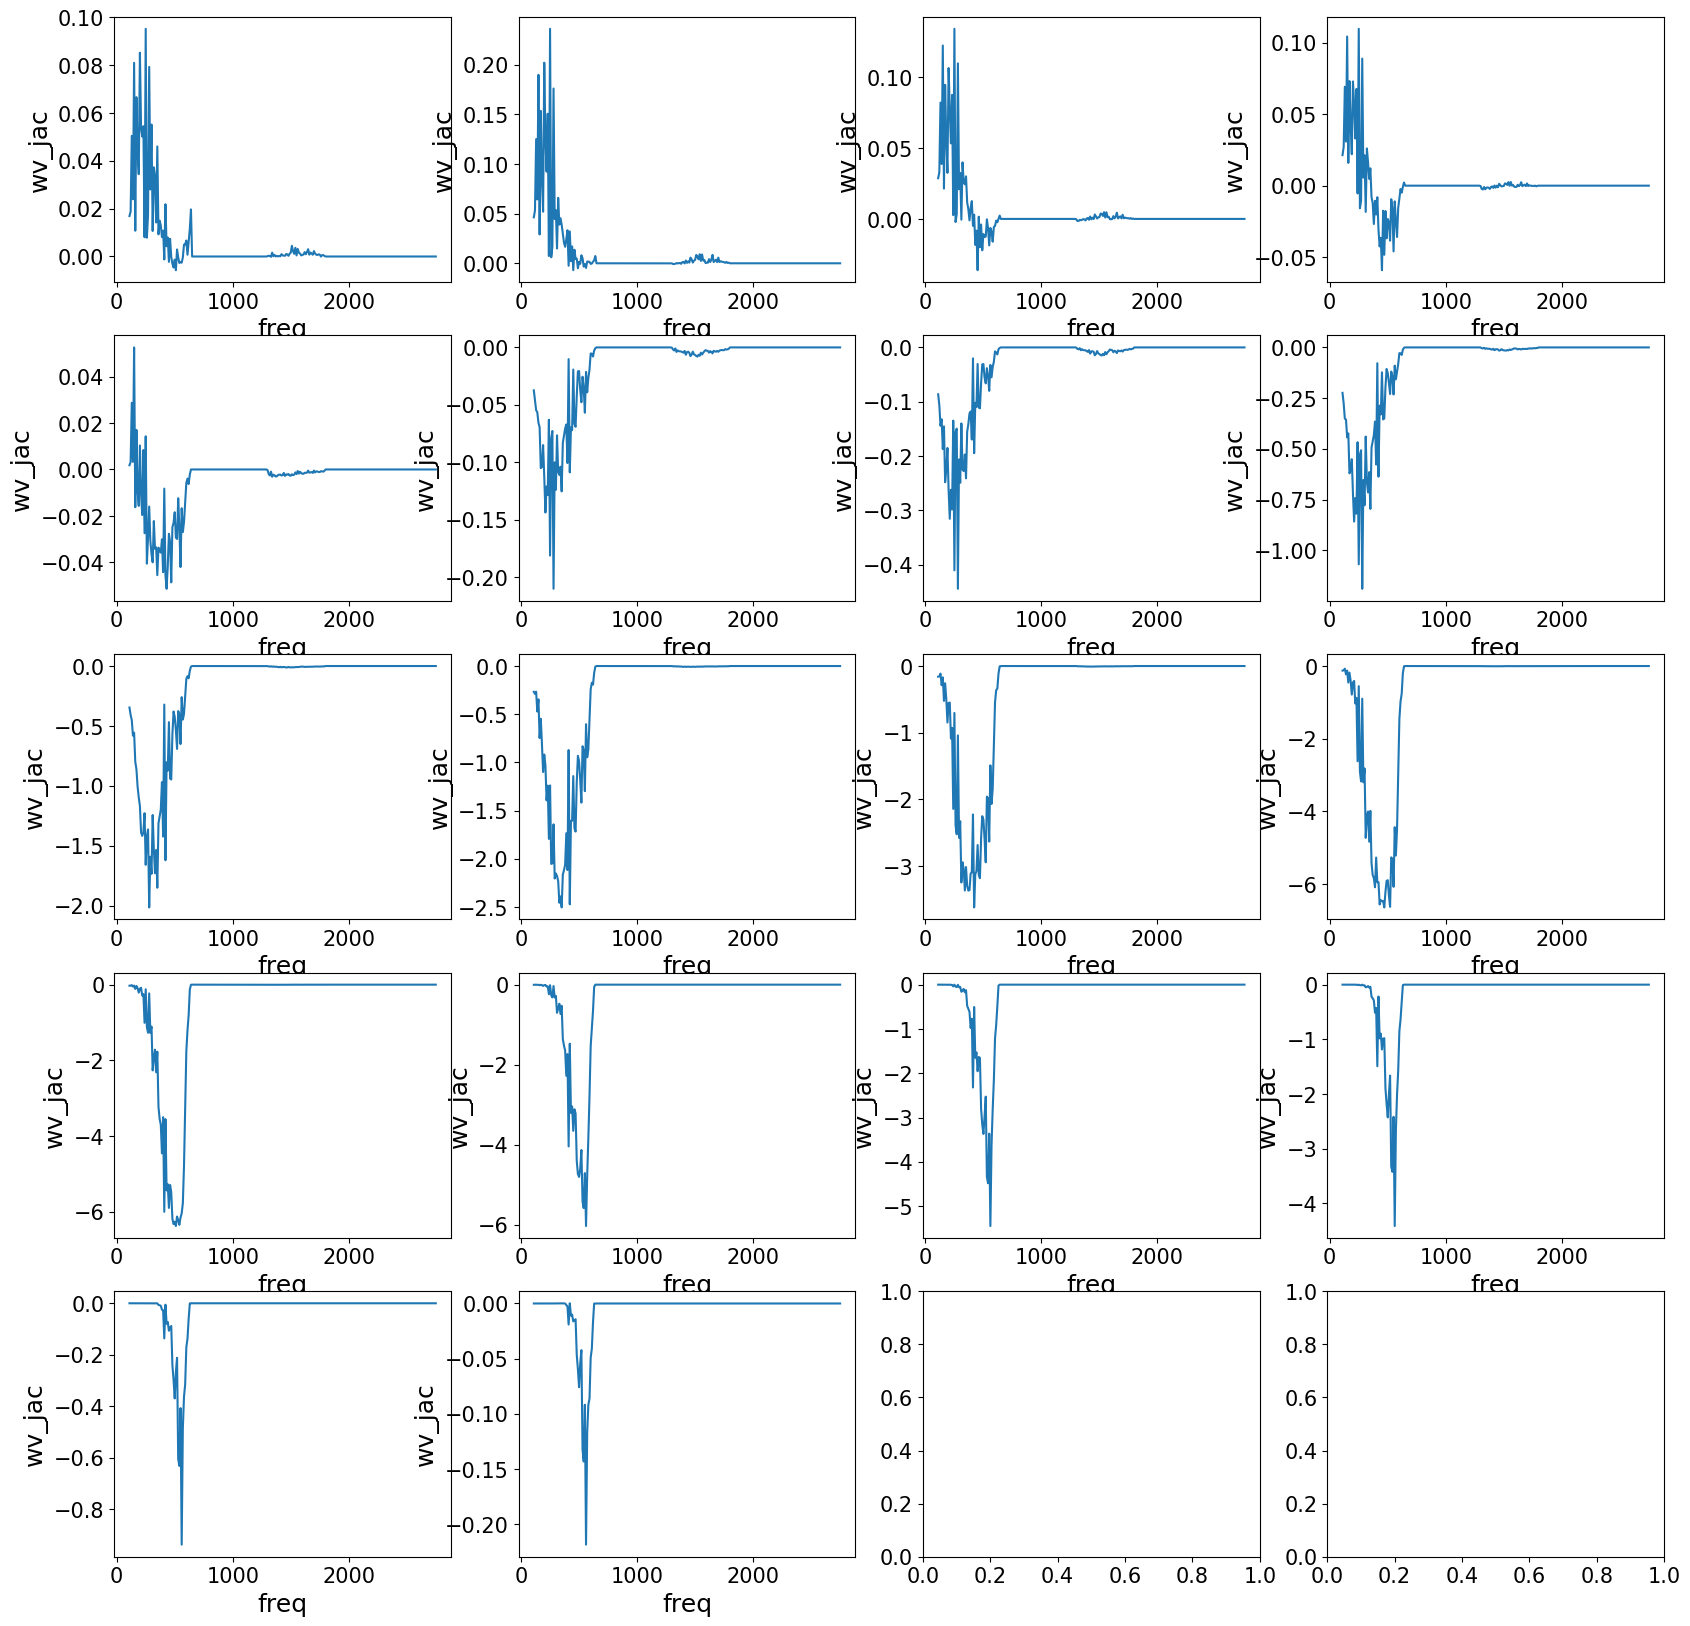

In [27]:
fig, axs = plt.subplots(5,4, figsize = (20,20))
for lev, ax in zip(coso.plev, axs.flatten()):
    coso.sel(plev = lev).plot(ax = ax)
    print(lev.values, coso.sel(plev = lev).mean().values, coso.sel(plev = lev).min().values, coso.sel(plev = lev).max().values)
    print(np.sum(np.isnan(coso.sel(plev = lev).values)))
    print(np.sum(coso.sel(plev = lev).values == 0))
    #ax.set_yscale('log')
    #ax.set_ylim(1e-16, 1e-1)
    ax.set_title('')

In [40]:
coso3 = xr.open_dataset('/lus/h2resw01/scratch/itsf/kernel/allsky_radiance_hybrid/spectral_radiance_kernel_longwave_05_cloudy_nadir_hybrid.nc')

In [41]:
coso3 = ctl.global_mean(coso3.wv_jac)

In [42]:
coso3

<xarray.DataArray 'wv_jac' (lev: 18, freq: 265)> Size: 38kB
array([[ 4.33443255e-03,  7.04455772e-03,  1.05853486e-02, ...,
        -2.95516432e-08, -2.21019490e-08, -3.20767659e-08],
       [ 9.90863129e-03,  1.33158028e-02,  2.67200301e-02, ...,
        -9.65333170e-08, -7.40620359e-08, -1.10571484e-07],
       [ 6.34396127e-03,  8.30761303e-03,  1.81622563e-02, ...,
        -1.05024338e-07, -8.02891946e-08, -1.20383575e-07],
       ...,
       [-9.82286313e-06, -7.19511234e-06, -6.47215458e-07, ...,
        -2.75689821e-07, -2.14912699e-07, -2.50684847e-07],
       [-2.20934754e-08, -2.01301672e-08, -1.31891915e-08, ...,
        -9.61063470e-08, -7.61747639e-08, -8.66493067e-08],
       [-1.00236078e-08, -1.04090459e-08, -8.09004061e-09, ...,
        -3.29461452e-08, -2.61943819e-08, -2.95459367e-08]],
      shape=(18, 265))
Coordinates:
  * lev      (lev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * freq     (freq) float64 2kB 110.0 120.0 130.0 ... 2.73e+03 2.74e+03 2.75e+03

1.0 0.001468870468683321 -0.0012022641601315102 0.03426390951251371
0
0
10.0 0.0023855054316613273 -0.004132045892341394 0.06446946122309749
0
0
20.0 0.001134124117610258 -0.005614843914119226 0.03788491090849916
0
0
30.0 0.00036695355910656676 -0.008722015452744996 0.028547173047792196
0
0
50.0 -0.001461230367240824 -0.018363121665237053 0.007981600628330669
0
0
70.0 -0.00396201959327267 -0.05603325511084671 5.4805111582797505e-08
0
0
100.0 -0.0076167619756176315 -0.1160850371610433 4.6926402505642395e-08
0
0
150.0 -0.022977793193130532 -0.3450528931203621 2.555524208961217e-07
0
0
200.0 -0.05008410783997471 -0.6219683230861356 1.8867864944804614e-07
0
0
250.0 -0.07123389520444083 -0.7202312994054803 1.8415422163379812e-07
0
0
300.0 -0.10586804146157254 -1.0419354075182596 7.435746400371094e-08
0
0
400.0 -0.1971634388337044 -1.8276066629054961 1.1002240086851675e-11
0
0
500.0 -0.16497899314243825 -1.7299224412843721 1.5934702520182972e-11
0
0
600.0 -0.11654645461420858 -1.665818067327

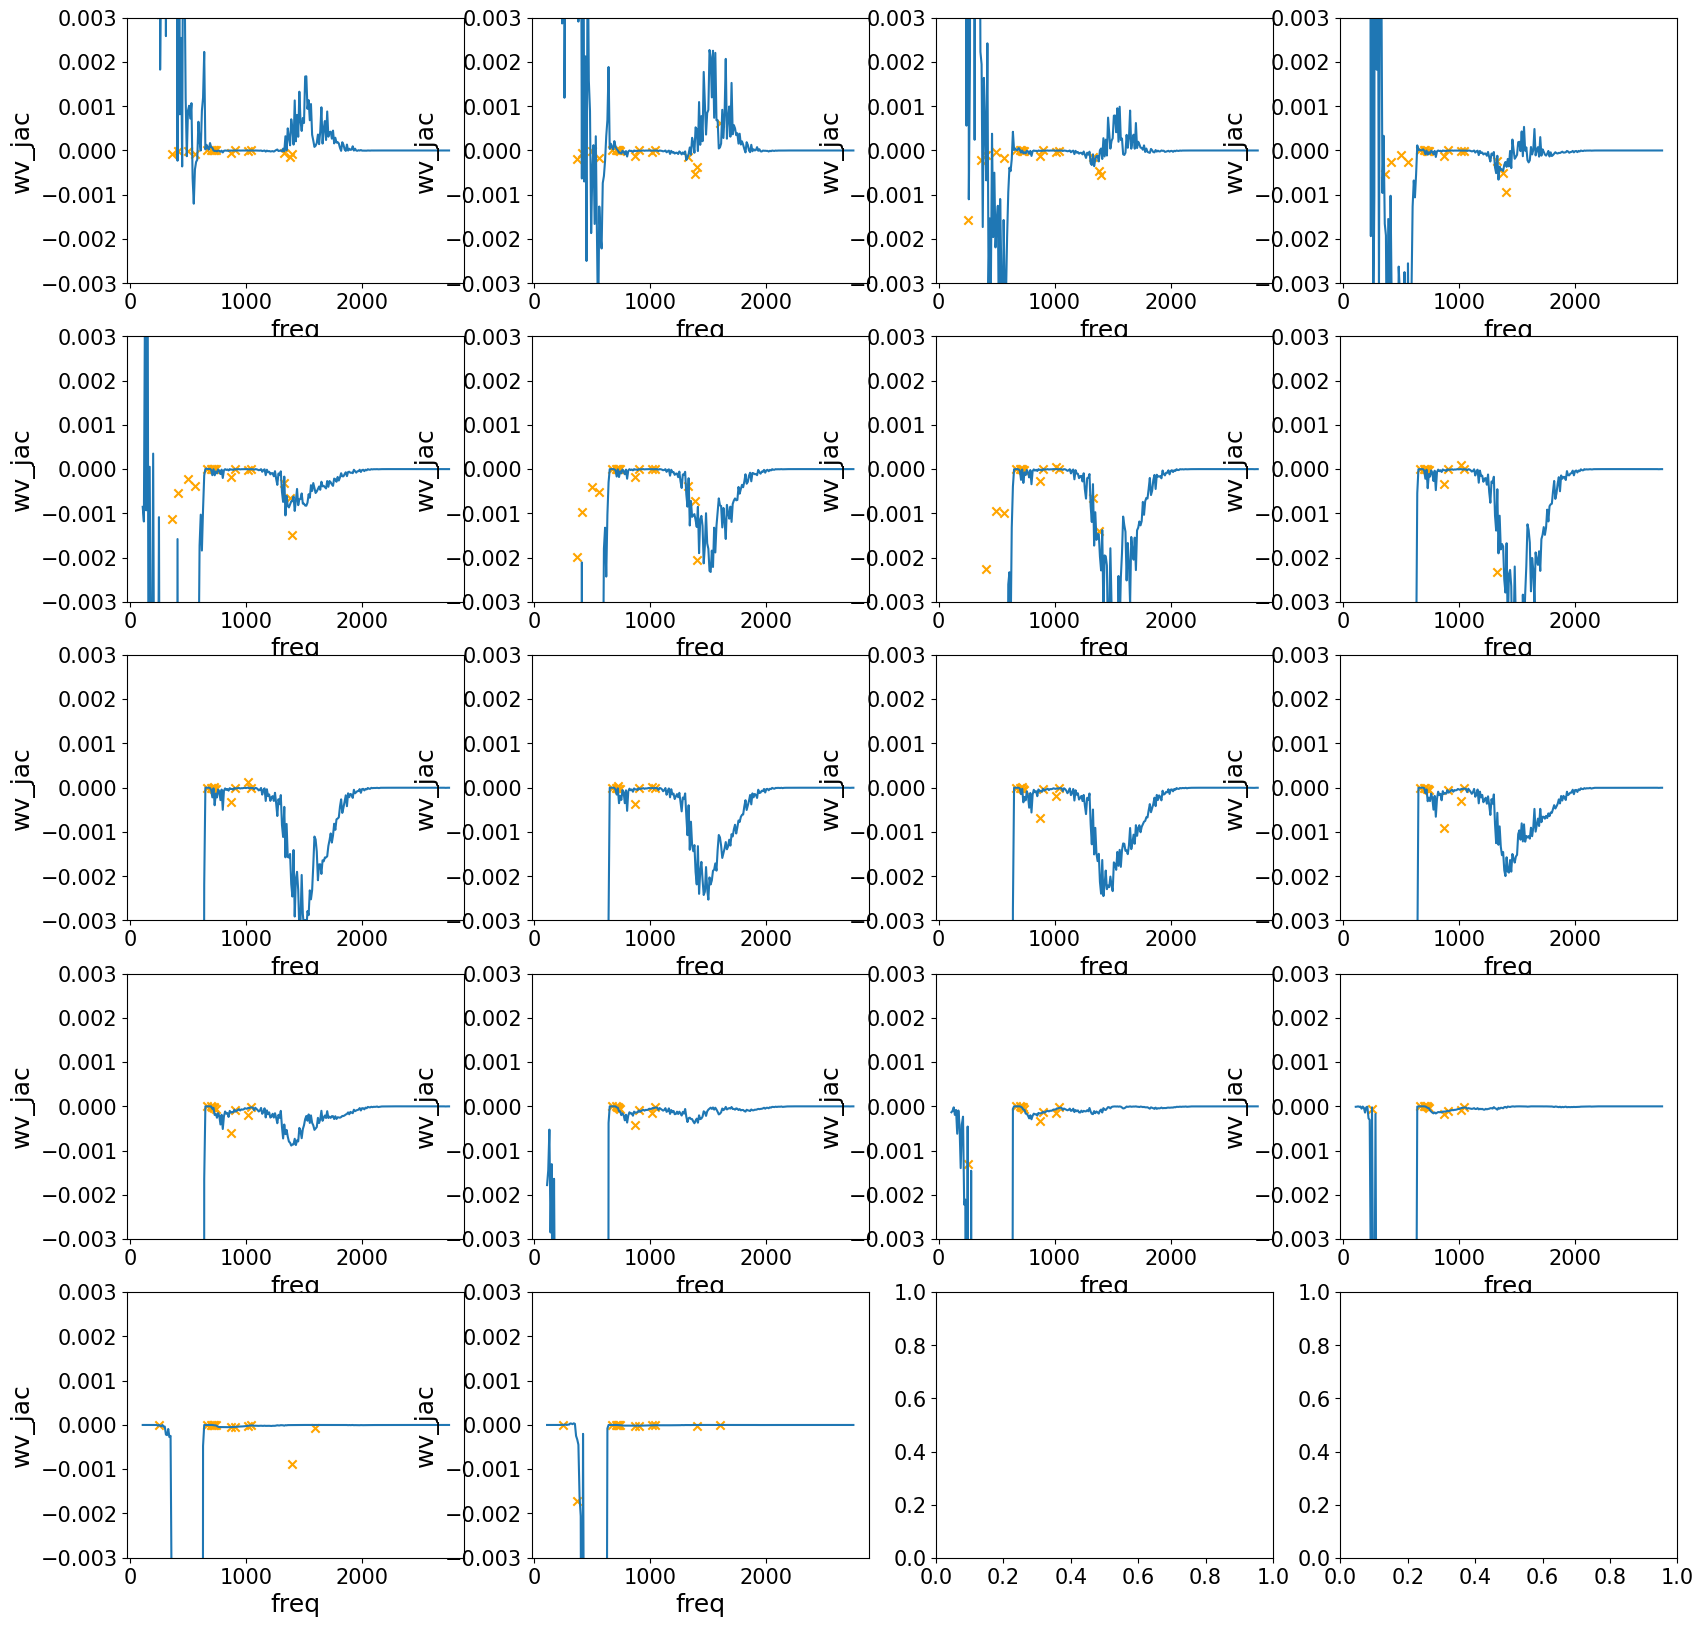

In [52]:
fig, axs = plt.subplots(5,4, figsize = (20,20))
for lev, ax in zip(coso3.lev, axs.flatten()):
    coso3.sel(lev = lev).plot(ax = ax)
    ax.scatter(coso_cha.freq, coso_cha.sel(lev = lev).values, color = 'orange', marker = 'x')
    print(lev.values, coso3.sel(lev = lev).mean().values, coso3.sel(lev = lev).min().values, coso3.sel(lev = lev).max().values)
    print(np.sum(np.isnan(coso3.sel(lev = lev).values)))
    print(np.sum(coso3.sel(lev = lev).values == 0))
    #ax.set_yscale('log')
    ax.set_ylim(-0.003, 0.003)
    ax.set_title('')

In [45]:
coso_cha = xr.open_dataset('/lus/h2resw01/scratch/itsf/kernel/allsky_radiance_hybrid/spectral_radiance_kernel_longwave_05_cloudy_channels_hybrid.nc')

In [47]:
coso_cha = ctl.global_mean(coso_cha.wv_jac)

In [48]:
coso_cha

<xarray.DataArray 'wv_jac' (lev: 18, freq: 19)> Size: 3kB
array([[ 1.07699930e-02, -8.40884512e-05, -1.92376193e-05,
        -3.65227691e-06, -6.87822967e-05,  4.03383218e-06,
         4.03790855e-07,  6.30199327e-08,  4.37346391e-06,
         1.29340108e-07, -2.52717989e-07, -4.81212825e-05,
        -4.56328948e-11, -1.06046235e-05,  5.65776461e-08,
        -6.62593919e-05, -1.54338522e-04, -7.27373860e-05,
         3.14985305e-03],
       [ 3.16507954e-03, -1.91719774e-04, -6.80730882e-05,
        -1.87104381e-05, -1.58846649e-04,  2.29510068e-06,
         6.41739816e-07,  5.37615736e-08,  3.26868677e-06,
        -4.23119177e-07, -5.64338843e-07, -1.29144474e-04,
        -4.02209522e-10, -3.77663625e-05, -2.79781947e-07,
        -1.37839164e-04, -5.22960592e-04, -3.72323536e-04,
         6.28877763e-04],
       [-1.57352710e-03, -2.24718928e-04, -1.03103411e-04,
        -3.53868078e-05, -1.67951598e-04,  1.17591083e-07,
         1.65114068e-07, -1.07113991e-07, -2.86136212e-06,
        -1.10103224e-06, -1.49713539e-06, -1.13875170e-04,
        -8.27314540e-10, -2.59589860e-05, -1.39516659e-06,
        -1.54468832e-04, -4.61026814e-04, -5.47604542e-04,
...
        -1.49949749e+00, -1.82801619e+00, -4.49326398e-10,
         7.31389419e-10, -1.22108121e-06, -1.73342080e-06,
        -9.15158931e-06, -2.91772190e-05, -1.68844077e-04,
        -9.87261868e-05, -7.72321846e-05, -1.72734012e-05,
        -4.91024598e-01, -3.04533874e-01, -4.09004831e-02,
        -4.41568494e-03],
       [-2.13713336e-08, -1.78260268e-02, -8.59530945e-02,
        -2.89989532e-01, -4.68357217e-01, -1.15515471e-10,
        -2.72078902e-11, -1.15399569e-07, -3.69713804e-07,
        -2.17771529e-06, -8.43858239e-06, -4.93375960e-05,
        -4.33573301e-05, -2.33873270e-05, -7.65974377e-06,
        -1.53676931e-01, -3.85781534e-02, -8.80072075e-04,
        -6.83206881e-05],
       [-7.09968745e-08, -1.71391218e-03, -1.50976550e-02,
        -6.50696476e-02, -1.18749993e-01, -3.19659319e-11,
        -7.52308324e-12, -2.11267903e-08, -1.07161249e-07,
        -6.70406125e-07, -2.73564849e-06, -1.62832162e-05,
        -1.62083870e-05, -7.89691477e-06, -2.86768664e-06,
        -5.47551993e-02, -9.22255319e-03, -1.42898213e-05,
         1.63321831e-06]])
Coordinates:
  * lev      (lev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * freq     (freq) float64 152B 250.0 365.2 410.2 ... 1.4e+03 1.596e+03

In [28]:
coso2 = ctl.global_mean(kernel.kernel[('clr', 'wv_lw_lin')].mean('month'))

In [29]:
coso2.load()

<xarray.DataArray 'wv_jac' (plev: 18, freq: 265)> Size: 38kB
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.61877766e-07, -1.29321404e-07, -1.80858767e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -5.16731069e-07, -4.19215900e-07, -6.02960318e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -5.64929965e-07, -4.56953811e-07, -6.59073009e-07],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.33355944e-06, -1.09134335e-06, -1.21654766e-06],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -4.13061723e-07, -3.37576667e-07, -3.73626566e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -1.15148350e-07, -9.12476999e-08, -1.03062553e-07]],
      shape=(18, 265))
Coordinates:
  * plev     (plev) float64 144B 1.0 10.0 20.0 30.0 ... 700.0 850.0 925.0 1e+03
  * freq     (freq) float64 2kB 110.0 120.0 130.0 ... 2.73e+03 2.74e+03 2.75e+03

1.0 1.8287769985933994e-05 -0.0006405716573305149 0.002021804433521269
0
104
10.0 -1.7773928332917456e-05 -0.00101470587105659 0.0012055281518500514
0
104
20.0 -6.236874674158176e-05 -0.0017693712158328863 0.0003353024455801583
0
104
30.0 -9.588178815228597e-05 -0.0023132193635852353 0.00028796664610435466
0
104
50.0 -9.159146009837963e-05 -0.0016059843720769298 6.319977500626728e-05
0
104
70.0 -8.577313900173794e-05 -0.0013427253319880912 4.268669500787789e-06
0
104
100.0 -0.0001308694183228296 -0.0022114712879615903 7.230264446198917e-07
0
104
150.0 -0.00017751915835229428 -0.0028906312918728226 2.037659777258972e-06
0
104
200.0 -0.00017580948315237157 -0.002598462785659502 7.527179270330575e-07
0
104
250.0 -0.00016683686750826584 -0.0022315969884213627 3.0434938243545893e-07
0
104
300.0 -0.00021478022505622471 -0.0025528362931635756 1.1678860134818462e-07
0
104
400.0 -0.0002509142409536401 -0.003020020994584767 0.0
0
104
500.0 -0.000194103912753363 -0.0023166670516318916 0.0
0
104
6

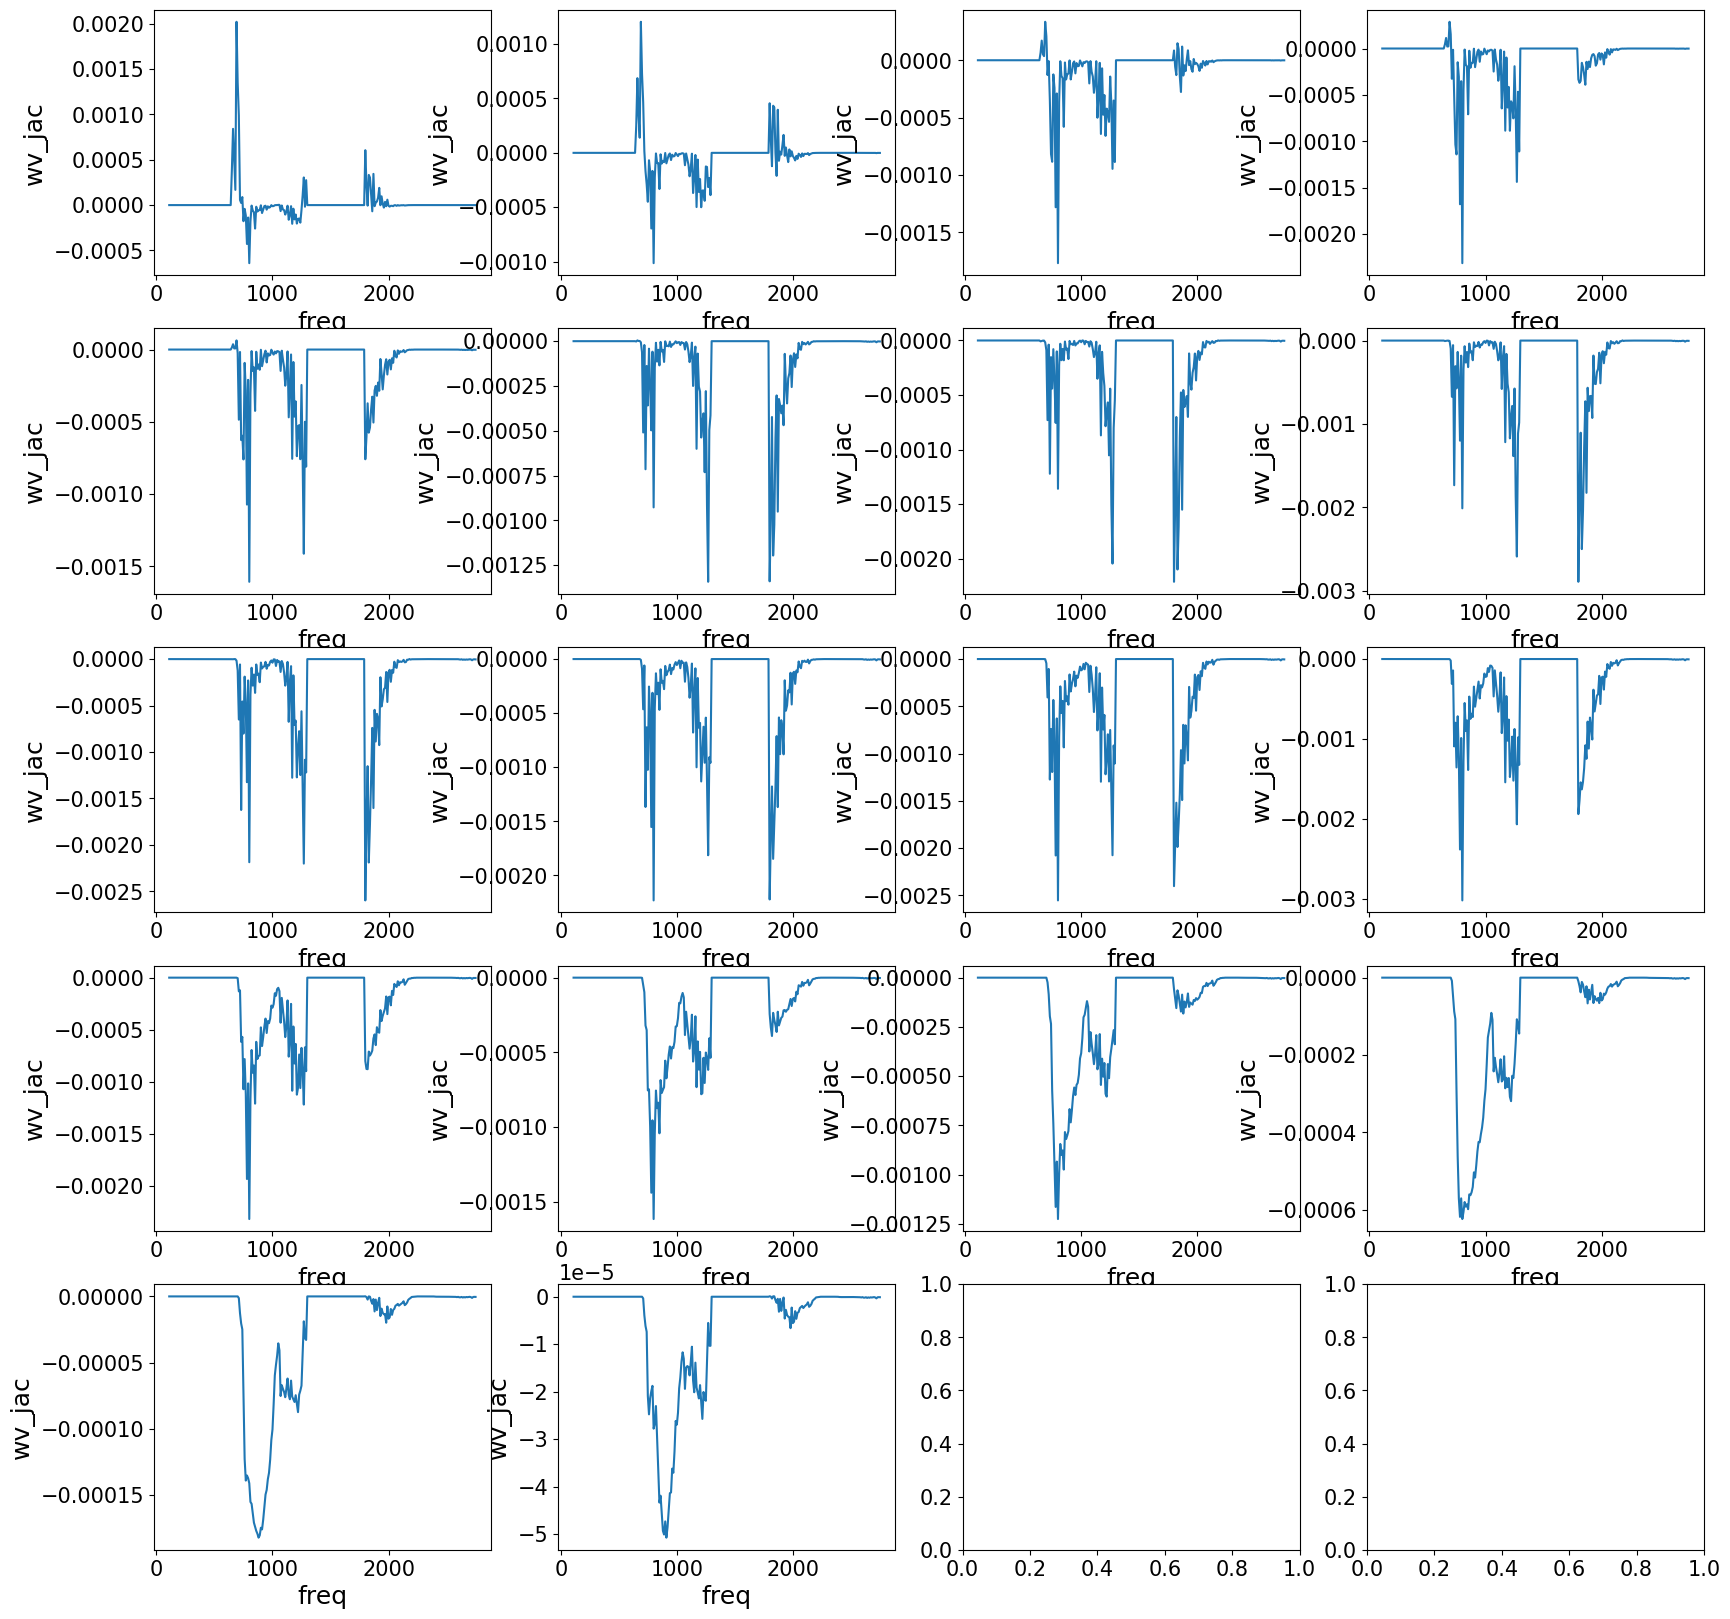

In [30]:
fig, axs = plt.subplots(5,4, figsize = (20,20))
for lev, ax in zip(coso2.plev, axs.flatten()):
    coso2.sel(plev = lev).plot(ax = ax)
    print(lev.values, coso2.sel(plev = lev).mean().values, coso2.sel(plev = lev).min().values, coso2.sel(plev = lev).max().values)
    print(np.sum(np.isnan(coso2.sel(plev = lev).values)))
    print(np.sum(coso2.sel(plev = lev).values == 0))
    #ax.set_yscale('log')
    #ax.set_ylim(1e-16, 1e-1)
    ax.set_title('')

In [ ]:
# fig, ax = plt.subplots()
for lev in coso.plev:
    print(lev, np.sum(coso.sel(plev = lev) == 0.))
# ax.set_yscale('log')

In [5]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_ERA5_ok/'
dRt = xr.open_mfdataset(cart_out + 'dRt*clr.nc')
dRt.load()
dRt.close()

In [15]:
cart_out_h = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/fb_HUANG_ok/'
dRt_h = xr.open_mfdataset(cart_out_h + 'dRt*clr.nc')
dRt_h.load()
dRt_h.close()

In [8]:
gtas = ctl.global_mean(experiment.ds_anom.tas).groupby('time.year').mean().compute()

In [9]:
dRt['tot'] = dRt['albedo'] * 0.
for var in dRt.data_vars:
    if var in ['water-vapor_lw', 'water-vapor_sw', 'tot']: 
        continue
    elif var == 'water-vapor':
        dRt['tot'] += dRt[var]
    else:
        dRt['tot'] += dRt[var]

In [10]:
net_toa_cs = ctl.global_mean(experiment.ds_anom['Net0']).compute()
net_toa_cs_yr = net_toa_cs.groupby('time.year').mean()

In [12]:
%matplotlib inline

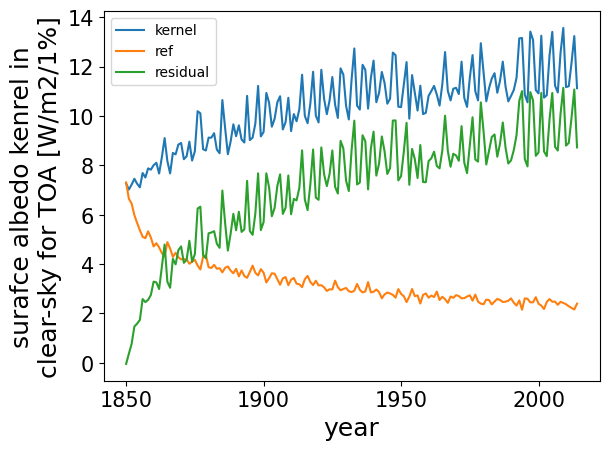

In [14]:
plt.figure()
(5.3 + dRt['tot']).plot(label = 'kernel')
plt.plot(np.arange(1850, 2015), net_toa_cs_yr.values, label = 'ref')
plt.plot(np.arange(1850, 2015), 5.3 + dRt['tot'].values - net_toa_cs_yr.values, label = 'residual')
plt.legend()

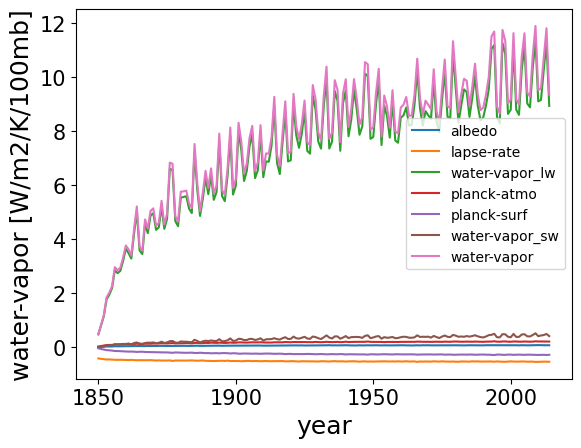

In [16]:
plt.figure()
for var in dRt_h.data_vars:
    (dRt[var] - dRt_h[var]).plot(label = var)
plt.legend()

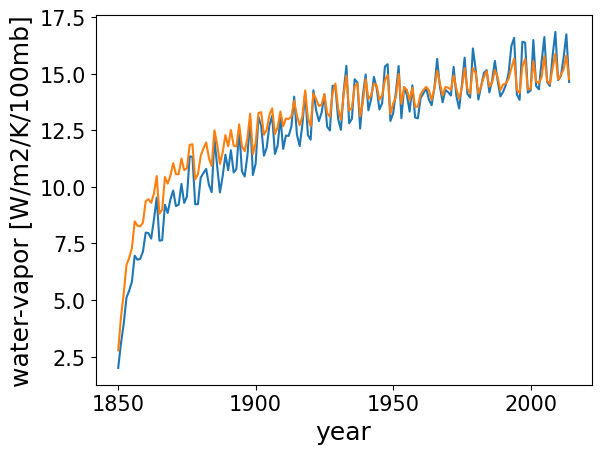

In [19]:
plt.figure()
(0.7*dRt['water-vapor']).plot()
dRt_h['water-vapor'].plot()

(0.0, 7.568741208314895)

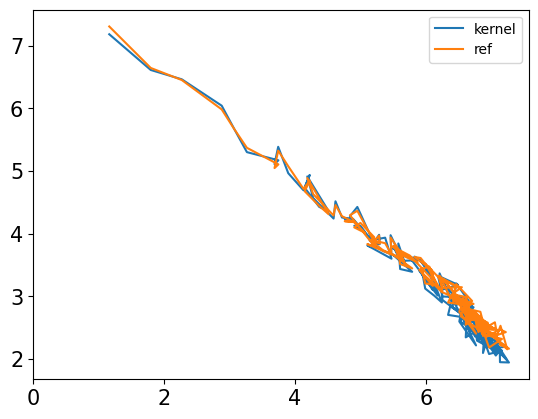

In [20]:
plt.figure()
plt.plot(gtas, 5.3+ dRt['tot'], label = 'kernel')
plt.plot(gtas, net_toa_cs_yr.values, label = 'ref')
#plt.plot(gtas, 6 + dRt['tot'].values - net_toa_cs_yr.values, label = 'residual')
plt.legend()
plt.xlim(0, None)

In [21]:
cart_out = '/perm/ccff/lavori/tunecs/fbcalc/ece3_abrupt/'

dRt_cld = xr.open_mfdataset(cart_out + 'dRt*cld.nc')
dRt_cld.load()
dRt_cld.close()

In [28]:
coso = xr.load_dataset(cart_out + 'dRt_cloud_global.nc')
dRt_cld['cloud'] = coso['cloud']

In [31]:
dRt_cld

<xarray.Dataset> Size: 7kB
Dimensions:         (year: 165)
Coordinates:
  * year            (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013 2014
Data variables:
    albedo          (year) float32 660B 0.3618 0.7246 1.024 ... 3.603 3.628
    lapse-rate      (year) float32 660B 2.615 2.214 2.461 ... 3.024 2.788 3.014
    water-vapor_lw  (year) float32 660B 2.08 3.134 3.918 ... 11.32 11.77 10.89
    planck-atmo     (year) float32 660B -3.213 -4.948 -6.398 ... -21.16 -20.19
    planck-surf     (year) float32 660B -0.8291 -1.234 -1.557 ... -4.943 -4.756
    water-vapor_sw  (year) float32 660B 0.3447 0.5056 0.6458 ... 1.983 1.878
    water-vapor     (year) float32 660B 2.425 3.639 4.564 ... 13.25 13.76 12.77
    tot             (year) float32 660B 1.36 0.3963 0.09247 ... -5.951 -5.534
    cloud           (year) float32 660B -0.03326 -0.5542 0.1184 ... 0.4987 1.034

In [35]:
dRt_cld['tot'] = dRt_cld['albedo'] * 0.
for var in dRt_cld.data_vars:
    if var in ['water-vapor_lw', 'water-vapor_sw', 'tot']: 
        continue
    elif var == 'water-vapor':
        dRt_cld['tot'] += dRt_cld[var]
    else:
        dRt_cld['tot'] += dRt_cld[var]

In [23]:
net_toa = ctl.global_mean(experiment.ds_anom['Net']).compute()
net_toa_yr = net_toa.groupby('time.year').mean()

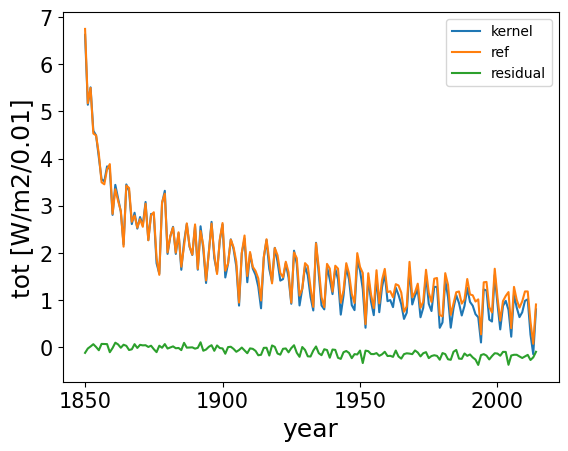

In [36]:
plt.figure()
(5.3 + dRt_cld['tot']).plot(label = 'kernel')
plt.plot(np.arange(1850, 2015), net_toa_yr.values, label = 'ref')
plt.plot(np.arange(1850, 2015), 5.3 + dRt_cld['tot'].values - net_toa_yr.values, label = 'residual')
plt.legend()

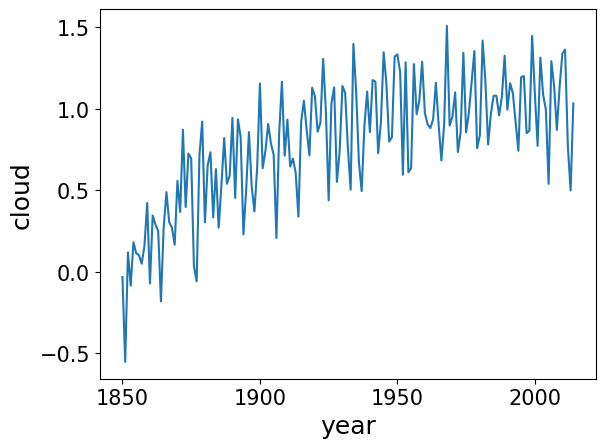

In [34]:
dRt_cld['cloud'].plot()

In [43]:
from scipy import stats
res = stats.linregress(gtas, net_toa_cs_yr.values)
res2 = stats.linregress(gtas,  dRt['tot'].values)

In [44]:
res.intercept, res2.intercept

(np.float64(8.213196722106327), np.float64(3.0722567539103576))

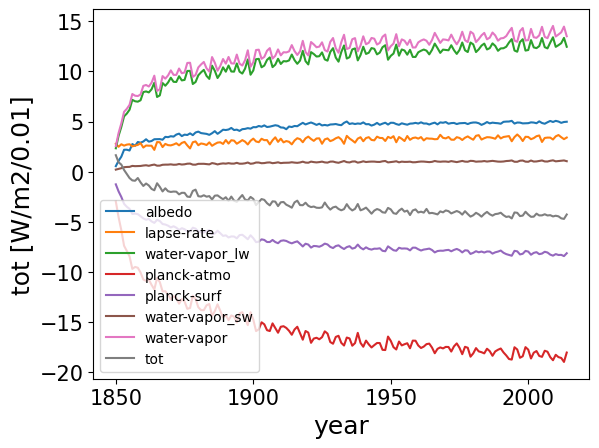

In [27]:
plt.figure()
for var in dRt.data_vars:
    dRt[var].plot(label = var)
plt.legend()

In [69]:
def dlnws(T):
    pliq0 = sfc.pliq(T)
    pice0 = sfc.pice(T)

    T1 = T + 1.0
    pliq1 = sfc.pliq(T1)
    pice1 = sfc.pice(T1)
    
    ws = np.where(T >= 273, pliq0, pice0)
    ws1 = np.where(T1 >= 273, pliq1, pice1)
    
    # Calculate the inverse of the derivative dws
    dws = ws / (ws1 - ws)

    return dws


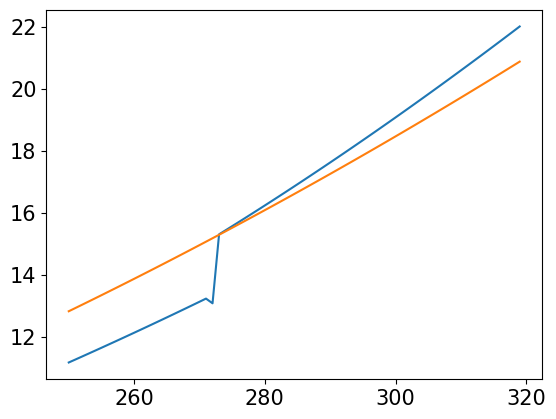

In [97]:
T = np.arange(250, 320, 1)

Rv = 461.5 # gas constant of water vapor
Lv = 2.25e+06 # latent heat of water vapor

plt.figure()
plt.plot(T, 1.15*dlnws(T))
plt.plot(T, T**2*Rv/Lv)

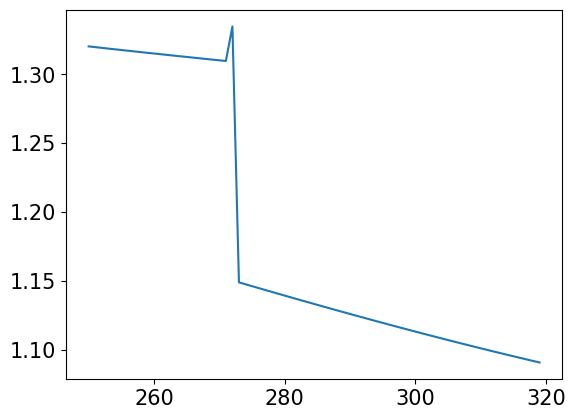

In [72]:
cos = T**2*Rv/Lv/(dlnws(T))

plt.plot(T, cos)

In [13]:
net_toa_cs_yr = net_toa_cs.groupby('time.year').mean()

In [37]:
net_toa_cs_yr.values

array([7.308304 , 6.6458297, 6.453192 , 5.984022 , 5.66587  , 5.3703313,
       5.1055408, 5.046495 , 5.325421 , 5.0757885, 4.714504 , 4.845753 ,
       4.676785 , 4.442925 , 4.3099585, 4.887945 , 4.630811 , 4.289773 ,
       4.4559236, 4.2777724, 4.189431 , 4.1983476, 4.188005 , 4.0135612,
       4.0990796, 4.171187 , 3.9435823, 3.7812254, 4.293669 , 4.3644543,
       3.8723257, 3.841706 , 3.968338 , 3.8118546, 3.832455 , 3.6655438,
       3.8469722, 3.9038842, 3.7368662, 3.626526 , 3.8087509, 3.5012958,
       3.7424479, 3.5143073, 3.4441173, 3.6814861, 3.9370415, 3.6474068,
       3.5418026, 3.795615 , 3.6494157, 3.2563684, 3.427183 , 3.6271775,
       3.610831 , 3.39098  , 3.1645133, 3.4231064, 3.473595 , 3.1453922,
       3.366625 , 3.4363873, 3.204731 , 3.1835623, 3.0654266, 3.387997 ,
       3.5204134, 3.276385 , 3.1490552, 3.3247232, 3.1351335, 3.1438634,
       3.0591507, 2.9111903, 2.978901 , 2.974324 , 3.327507 , 3.0627778,
       2.9385736, 2.9900656, 3.0319207, 2.89991  , 

In [23]:
dRt['tot']

<xarray.DataArray 'tot' (year: 150)> Size: 1kB
dask.array<add, shape=(150,), dtype=float64, chunksize=(150,), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 1996 1997 1998 1999
    height   float64 8B 2.0
Attributes:
    regrid_method:  bilinear
    units:          W/m2/0.01
    longname:       alb kernel at toa in clear sky

In [41]:
mask = sfc.mask_strato(experiment.ds_anom.ta)

In [42]:
mask.chunks

((120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  60),
 (24,),
 (73,),
 (144,))

In [44]:
mask.dims

('time', 'plev', 'lat', 'lon')

In [43]:
experiment.ds_anom.ta.dims

('time', 'plev', 'lat', 'lon')

In [33]:
experiment.ds_anom.ta.chunks

((120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  120,
  60),
 (24,),
 (73,),
 (144,))

In [30]:
experiment.ds_anom

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 1980, lon: 144, lat: 73, plev: 24)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
Data variables:
    rlut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 24, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    alb      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    hus_log  (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 24, 73, 144), meta=np.ndarray>

In [58]:
experiment.ds_anom

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 1980, lon: 144, lat: 73, plev: 24)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
Data variables:
    rlut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 24, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    alb      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    hus_log  (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 24, 73, 144), meta=np.ndarray>

In [13]:
config = sfc.load_config(config_file, variable_mapping_file = None)
kernel = sfc.Kernel("HUANG", config = config)

Time range for climatology: {'start': '2540-01-16 12:00:00', 'end': '2560-12-30 12:00:00'}
Time range for experiment: all
Loading kernel: HUANG


In [23]:
kernel.kernel[('clr', 't')].coords

Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [17]:
sfc.load_variable_mapping('configvariable.yaml', 'ece3_abrupt')

{'rename_map': {'test': 'gigi'}}

In [12]:
kernel.kernel

{('clr',
  't'): <xarray.DataArray 'lwkernel' (month: 12, plev: 24, lat: 73, lon: 144)> Size: 12MB
 array([[[[-0.07463066, -0.07463066, -0.07463066, ..., -0.07463066,
           -0.07463066, -0.07463066],
          [-0.07217614, -0.07238398, -0.07257514, ..., -0.07060996,
           -0.07101536, -0.07157823],
          [-0.06959023, -0.07003437, -0.07068681, ..., -0.06685756,
           -0.06763119, -0.06871069],
          ...,
          [        nan,         nan,         nan, ...,         nan,
                   nan,         nan],
          [        nan,         nan,         nan, ...,         nan,
                   nan,         nan],
          [        nan,         nan,         nan, ...,         nan,
                   nan,         nan]],
 
         [[-0.08866862, -0.08866862, -0.08866862, ..., -0.08866862,
           -0.08866862, -0.08866862],
          [-0.08632382, -0.08644177, -0.08656091, ..., -0.08597691,
           -0.08608963, -0.08622028],
          [-0.08618828, -0.08713357

In [19]:
kernel.dp

<xarray.DataArray 'dp' (plev: 24)> Size: 96B
array([0.255, 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 ,
       0.25 , 0.875, 1.   , 1.   , 1.   , 1.   , 0.625, 0.5  , 0.5  ,
       0.525, 0.35 , 0.165, 0.045, 0.025, 0.01 ], dtype=float32)
Coordinates:
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0

In [4]:
# from dask_jobqueue import SLURMCluster
# from dask.distributed import Client

# # Dask will automatically submit SLURM jobs for you
# cluster = SLURMCluster(
#     cores=4,
#     memory="128GB",
#     processes=4,
#     walltime="02:00:00",
#     #qos="np",
#     #account='spitfabi',
#     #interface='ib0'  # or 'eth0', depends on your HPC
#     job_extra_directives=[
#         "--account=spitfabi",
#         "--qos=np"
#         # "--constraint=haswell",
#         # "--exclusive",
#         # "--mail-type=END,FAIL",
#         # "--mail-user=your.email@domain.com"
#     ]
# )

# # Scale to desired number of workers
# cluster.scale(jobs=1)  # This submits 4 SLURM jobs

# # Connect client
# client = Client(cluster)

In [5]:
config['file_paths']['reference_dataset']

'/ec/res4/scratch/ccff/tunecs/picontrol_cmip6_r1_ok/**/*.nc'

In [7]:
orig_dir = '/ec/res4/scratch/ccff/tunecs/picontrol_cmip6_r1_ok/'

In [4]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

## First: loading raw data and (optionally) save remapped to disk

In [41]:
picont = sfc.Experiment('PI', orig_dir, variables = sfc.STD_VARS_NOALB)

In [38]:
picont

ClimateDataset(
  exp_type      = 'PI'
  variables  = {'ta', 'rlutcs', 'tas', 'rsus', 'rsutcs', 'hus', 'ts', 'rsds', 'rsut', 'rlut'}
  remap_dir  = remapped
  raw_data = 0 DataArray(s)
  ds    = []
)

In [10]:
picont.load_raw()

Loading raw data...
ta
rlutcs
tas
rsus
rsutcs
hus
ts
rsds
rsut
rlut


In [11]:
picont

ClimateDataset(
  exp_type      = 'PI'
  variables  = {'ta', 'rlutcs', 'tas', 'rsus', 'rsutcs', 'hus', 'ts', 'rsds', 'rsut', 'rlut'}
  remap_dir  = remapped
  raw_data = 10 DataArray(s)
  ds    = []
)

In [12]:
k = allkers[('clr', 'ts')]

In [13]:
picont.remap(target_ds = k, save_remapped = False)

Regridding...
Regridding completed in 0:00:07.004439
Regridding...
Regridding completed in 0:00:01.514409
Regridding...
Regridding completed in 0:00:01.450191
Regridding...
Regridding completed in 0:00:01.475297
Regridding...
Regridding completed in 0:00:01.429348
Regridding...
Regridding completed in 0:00:01.423311
Regridding...
Regridding completed in 0:00:01.398323
Regridding...
Regridding completed in 0:00:01.413034
Regridding...
Regridding completed in 0:00:01.386372
Regridding...
Regridding completed in 0:00:01.387154


### data are now loaded and remapped (but not computed!)

In [14]:
picont.ds

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 2400, plev: 19, lat: 73, lon: 144)
Coordinates:
  * time     (time) object 19kB 2500-01-16 12:00:00 ... 2699-12-16 12:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 8B 2.0
Data variables:
    ta       (time, plev, lat, lon) float32 2GB dask.array<chunksize=(12, 1, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    rsus     (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    hus      (time, plev, lat, lon) float32 2GB dask.array<chunksize=(12, 1, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    rsds     (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
    rlut     (time, lat, lon) float32 101MB dask.array<chunksize=(12, 73, 144), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### To save remapped data on disk 
- suggested for repeated calculations
- remapped data on disk take about 3 Gb per 150 years experiment

In [15]:
picont.remap(target_ds = k, save_remapped = True)

Regridding...
Regridding completed in 0:00:01.411791
Regridding...
Regridding completed in 0:00:01.388011
Regridding...
Regridding completed in 0:00:01.386587
Regridding...
Regridding completed in 0:00:01.385879
Regridding...
Regridding completed in 0:00:01.377442
Regridding...
Regridding completed in 0:00:01.394412
Regridding...
Regridding completed in 0:00:01.355975
Regridding...
Regridding completed in 0:00:01.359679
Regridding...
Regridding completed in 0:00:01.369954
Regridding...
Regridding completed in 0:00:01.355632
Saving remapped to disk
ta
rlutcs
tas
rsus
rsutcs
hus
ts
rsds
rsut
rlut


## Now load everything again, but already remapped!

In [6]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [8]:
picont = sfc.Experiment('PI', orig_dir)

In [9]:
picont.load_remapped()

/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preprocess = preproc)
/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preproce

In [18]:
sfc.check_lazy_loading(picont.ds)

=== Lazy Loading Status ===
hus                  ✓ Lazy     (  1917.4 MB,   20 chunks)
rlut                 ✓ Lazy     (   100.9 MB,   20 chunks)
rlutcs               ✓ Lazy     (   100.9 MB,   20 chunks)
rsds                 ✓ Lazy     (   100.9 MB,   20 chunks)
rsus                 ✓ Lazy     (   100.9 MB,   20 chunks)
rsut                 ✓ Lazy     (   100.9 MB,   20 chunks)
rsutcs               ✓ Lazy     (   100.9 MB,   20 chunks)
ta                   ✓ Lazy     (  1917.4 MB,   20 chunks)
tas                  ✓ Lazy     (   100.9 MB,   20 chunks)
ts                   ✓ Lazy     (   100.9 MB,   20 chunks)

Chunk structure:
Frozen({'time': (120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120), 'plev': (19,), 'lat': (73,), 'lon': (144,)})


In [10]:
picont.check_vars()

Computing albedo from rsus and rsds
Applying log to hus
rlut loaded
rsut loaded
ts loaded
ta loaded
rlutcs loaded
alb loaded
hus_log loaded
tas loaded
rsutcs loaded


In [20]:
picont.ds

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 2400, plev: 19, lon: 144, lat: 73)
Coordinates:
  * time     (time) object 19kB 2500-01-16 12:00:00 ... 2699-12-16 12:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
    height   float64 8B ...
Data variables:
    rlut     (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 19, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    alb      (time, lat, lon) float32 101MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    hus_log  (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 19, 73, 144), meta=np.ndarray>

### Now compute climatology

In [12]:
time_range_clim = config.get("time_range", {})
time_range_clim = time_range_clim if time_range_clim.get("start") and time_range_clim.get("end") else None

In [13]:
picont.compute_clim(time_range = time_range_clim)

In [82]:
picont.ds_clim

<xarray.Dataset> Size: 24MB
Dimensions:  (month: 12, plev: 19, lat: 73, lon: 144)
Coordinates:
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
    height   float64 8B 2.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    hus      (month, plev, lat, lon) float32 10MB 0.0003205 ... 2.067e-06
    rlut     (month, lat, lon) float32 505kB 164.0 164.0 164.0 ... 186.1 186.1
    rlutcs   (month, lat, lon) float32 505kB 172.7 172.7 172.7 ... 192.3 192.3
    rsds     (month, lat, lon) float32 505kB 0.0 0.0 0.0 ... 436.6 436.6 436.6
    rsus     (month, lat, lon) float32 505kB -1e-15 -1e-15 ... 360.5 360.5
    rsut     (month, lat, lon) float32 505kB 0.0 0.0 0.0 ... 393.6 393.6 393.6
    rsutcs   (month, lat, lon) float32 505kB 0.0 0.0 0.0 ... 387.4 387.4 387.4
    ta       (month, plev, lat, lon) float32 10MB 244.7 244.7 ... 291.0 291.0
    tas      (month, lat, lon) float32 505kB 241.2 241.2 241.2 ... 247.7 247.7
    ts       (month, lat, lon) float32 505kB 242.3 242.3 242.3 ... 235.1 235.1
    alb      (month, lat, lon) float32 505kB 0.0 0.0 0.0 ... 0.826 0.826 0.826

In [ ]:
picont

ClimateDataset(
  exp_type      = 'PI'
  variables (raw) = {'rsus', 'rsut', 'rlut', 'tas', 'hus', 'rsds', 'rsutcs', 'ta', 'ts', 'rlutcs'}
  variables = {'rsut', 'rlut', 'alb', 'tas', 'rsutcs', 'ta', 'ts', 'hus_log', 'rlutcs'}
  remap_dir  = remapped
  raw_data = 0 DataArray(s)
  ds    = ['rlut', 'rlutcs', 'rsut', 'rsutcs', 'ta', 'tas', 'ts', 'alb', 'hus_log']
)

## Now load experiment

In [83]:
config['file_paths']['experiment_dataset']

'/ec/res4/scratch/ccff/tunecs/abrupt_cmip6_r8/**/*.nc'

In [14]:
exp_dir = '/ec/res4/scratch/ccff/tunecs/abrupt_cmip6_r8/'

In [15]:
abrupt = sfc.Experiment('4x', exp_dir)

In [86]:
abrupt.load_raw()

Loading raw data...
ta
rlutcs
tas
rsus
rsutcs
hus
ts
rsds
rsut
rlut


In [87]:
abrupt.remap(target_ds = k, save_remapped = True)

Regridding...
Regridding completed in 0:00:01.442095
Regridding...
Regridding completed in 0:00:01.423933
Regridding...
Regridding completed in 0:00:01.380930
Regridding...
Regridding completed in 0:00:01.383844
Regridding...
Regridding completed in 0:00:01.366036
Regridding...
Regridding completed in 0:00:01.384191
Regridding...
Regridding completed in 0:00:01.357988
Regridding...
Regridding completed in 0:00:01.359217
Regridding...
Regridding completed in 0:00:01.338409
Regridding...
Regridding completed in 0:00:01.334201
Saving remapped to disk
ta
rlutcs
tas
rsus
rsutcs
hus
ts
rsds
rsut
rlut


In [16]:
abrupt.load_remapped()

In [14]:
abrupt.ds

<xarray.Dataset> Size: 4GB
Dimensions:  (time: 1980, plev: 19, lon: 144, lat: 73)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * plev     (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
    height   float64 8B ...
Data variables:
    hus      (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 19, 73, 144), meta=np.ndarray>
    rlut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsds     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsus     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 2GB dask.array<chunksize=(120, 19, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>

In [17]:
abrupt.check_vars()

Computing albedo from rsus and rsds
Applying log to hus
tas loaded
ts loaded
alb loaded
rlut loaded
rsut loaded
rsutcs loaded
hus_log loaded
rlutcs loaded
ta loaded


In [18]:
sfc.check_lazy_loading(abrupt.ds)

=== Lazy Loading Status ===
rlut                 ✓ Lazy     (    83.3 MB,   17 chunks)
rlutcs               ✓ Lazy     (    83.3 MB,   17 chunks)
rsut                 ✓ Lazy     (    83.3 MB,   17 chunks)
rsutcs               ✓ Lazy     (    83.3 MB,   17 chunks)
ta                   ✓ Lazy     (  1581.8 MB,   17 chunks)
tas                  ✓ Lazy     (    83.3 MB,   17 chunks)
ts                   ✓ Lazy     (    83.3 MB,   17 chunks)
alb                  ✓ Lazy     (    83.3 MB,   17 chunks)
hus_log              ✓ Lazy     (  1581.8 MB,   17 chunks)

Chunk structure:
Frozen({'time': (120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 60), 'lat': (73,), 'lon': (144,), 'plev': (19,)})


In [19]:
sfc.check_lazy_loading(picont.ds)

=== Lazy Loading Status ===
rlut                 ✓ Lazy     (   100.9 MB,   20 chunks)
rlutcs               ✓ Lazy     (   100.9 MB,   20 chunks)
rsut                 ✓ Lazy     (   100.9 MB,   20 chunks)
rsutcs               ✓ Lazy     (   100.9 MB,   20 chunks)
ta                   ✓ Lazy     (  1917.4 MB,   20 chunks)
tas                  ✓ Lazy     (   100.9 MB,   20 chunks)
ts                   ✓ Lazy     (   100.9 MB,   20 chunks)
alb                  ✓ Lazy     (   100.9 MB,   20 chunks)
hus_log              ✓ Lazy     (  1917.4 MB,   20 chunks)

Chunk structure:
Frozen({'time': (120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120), 'lat': (73,), 'lon': (144,), 'plev': (19,)})


## Pipeline with clim

In [6]:
# Load Picontrol
orig_dir = '/ec/res4/scratch/ccff/tunecs/picontrol_cmip6_r1_ok/'
picont = sfc.Experiment('PI', orig_dir)
# picont.load_raw()
# picont.remap(target_ds = k, save_remapped = True)
picont.load_remapped()
picont.check_vars()
picont.vertical_interp(k)

# Load 4x
exp_dir = '/ec/res4/scratch/ccff/tunecs/abrupt_cmip6_r8/'
abrupt = sfc.Experiment('4x', exp_dir)
# abrupt.load_raw()
# abrupt.remap(target_ds = k, save_remapped = True)
abrupt.load_remapped()
abrupt.check_vars()
abrupt.vertical_interp(k)

# Compute climatology
time_range_clim = config.get("time_range", {})
time_range_clim = time_range_clim if time_range_clim.get("start") and time_range_clim.get("end") else None

picont.compute_clim(time_range=config['time_range'], compute = True)

# Compute anomaly
abrupt.compute_anom_clim(picont)


/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preprocess = preproc)
/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preproce

Computing albedo from rsus and rsds
Applying log to hus
alb loaded
tas loaded
rlutcs loaded
hus_log loaded
rlut loaded
rsutcs loaded
rsut loaded
ts loaded
ta loaded
check vertical dimension
Rewriting vertical coordinates from Pa to hPa


/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preprocess = preproc)
/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py:202: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  self.ds = xr.open_mfdataset(files, combine = "by_coords", use_cftime=True, chunks = self.chunks_remap, preproce

Computing albedo from rsus and rsds
Applying log to hus
alb loaded
tas loaded
rlutcs loaded
hus_log loaded
rlut loaded
rsutcs loaded
rsut loaded
ts loaded
ta loaded
check vertical dimension
Rewriting vertical coordinates from Pa to hPa


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


In [11]:
picont.ds_clim.nbytes/1e6

27.752748

In [7]:
abrupt.ds_anom.nbytes/1e6

4579.044012

In [7]:
cart_k = '/perm/ccff/radiative_kernels/Huang/toa/'
k = allkers[('cld', 't')]
vlevs = xr.load_dataset( cart_k + 'dp.nc')  
vlevs=vlevs.rename({'player': 'plev'})

In [32]:
k.sizes

Frozen({'month': 12, 'plev': 24, 'lat': 73, 'lon': 144})

In [8]:
pressure_path = config['file_paths'].get('pressure_data', None)

if pressure_path:  # If pressure data is specified, load it
    print("Loading surface pressure data...")
    ps_files = sorted(glob.glob(pressure_path))  # Support for patterns like "*.nc"
    if not ps_files:
        raise FileNotFoundError(f"No matching pressure files found for pattern: {pressure_path}")
    
    surf_pressure = xr.open_mfdataset(ps_files, combine='by_coords')
    #surf_pressure = standardize_names(surf_pressure, dataset_type, variable_mapping_file)


psclim = surf_pressure.groupby('time.month').mean(dim='time')
psye = psclim['ps'].mean('month')

Loading surface pressure data...


/etc/ecmwf/ssd/ssd1/jupyterhub/ccff-jupyterhub/tmpdirs/ccff.12889531/ipykernel_3251126/2057382475.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  surf_pressure = xr.open_mfdataset(ps_files, combine='by_coords')


In [9]:
import numpy as np

In [14]:
psye_rg = sfc.regrid(psye, k).compute()

Regridding...
Regridding completed in 0:00:01.304330


In [15]:
psye_rg

<xarray.DataArray 'ps' (lat: 73, lon: 144)> Size: 42kB
array([[101414.85 , 101414.85 , 101414.85 , ..., 101414.85 , 101414.85 ,
        101414.85 ],
       [101378.87 , 101380.8  , 101382.73 , ..., 101349.41 , 101359.234,
        101369.055],
       [101322.08 , 101324.7  , 101327.336, ..., 101338.47 , 101325.41 ,
        101323.734],
       ...,
       [ 71209.914,  71054.6  ,  70899.19 , ...,  71947.19 ,  71655.95 ,
         71432.99 ],
       [ 70801.93 ,  70658.59 ,  70515.24 , ...,  71367.29 ,  71178.83 ,
         70990.39 ],
       [ 69378.44 ,  69378.44 ,  69378.44 , ...,  69378.44 ,  69378.44 ,
         69378.44 ]], shape=(73, 144), dtype=float32)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    regrid_method:  bilinear

In [16]:
wid_mask = np.empty([len(vlevs.plev)] + list(psye_rg.shape))

In [18]:
for ila in range(len(psye_rg.lat)):
    for ilo in range(len(psye_rg.lon)):
        ind = np.where((psye_rg[ila, ilo].values - vlevs.plev.values) > 0)[0][0]
        wid_mask[:ind, ila, ilo] = np.nan
        wid_mask[ind, ila, ilo] = psye_rg[ila, ilo].values - vlevs.plev.values[ind]
        wid_mask[ind+1:, ila, ilo] = vlevs.dp.values[ind+1:]

wid_mask = xr.DataArray(wid_mask, dims = k.dims[1:], coords = k.drop('month').coords)

/etc/ecmwf/ssd/ssd1/jupyterhub/ccff-jupyterhub/tmpdirs/ccff.12889531/ipykernel_3251126/3861936660.py:8: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  wid_mask = xr.DataArray(wid_mask, dims = k.dims[1:], coords = k.drop('month').coords)


In [20]:
wid_mask.nbytes/1e6

2.018304

In [19]:
mask = sfc.mask_strato(abrupt.ds.ta)

In [22]:
mask.data

dask.array<where, shape=(23, 1980, 73, 144), dtype=float64, chunksize=(1, 120, 73, 144), chunktype=numpy.ndarray>

In [33]:
abrupt.ds.plev

<xarray.DataArray 'plev' (plev: 24)> Size: 96B
array([1000. ,  975. ,  950. ,  925. ,  900. ,  875. ,  850. ,  825. ,  800. ,
        775. ,  725. ,  625. ,  525. ,  425. ,  325. ,  237.5,  187.5,  137.5,
         85. ,   40. ,   15. ,    6. ,    2.5,    1. ], dtype=float32)
Coordinates:
    height   float64 8B ...
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
Attributes:
    units:    hPa

In [29]:
mask

<xarray.DataArray (plev: 23, time: 1980, lat: 73, lon: 144)> Size: 4GB
dask.array<where, shape=(23, 1980, 73, 144), dtype=float64, chunksize=(1, 120, 73, 144), chunktype=numpy.ndarray>
Coordinates:
    height   float64 8B 2.0
  * plev     (plev) float64 184B 1e+03 975.0 950.0 925.0 ... 40.0 15.0 6.0 2.5
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0

In [20]:
from importlib import reload
reload(sfc)

<module 'spectfbcalc_lib' from '/etc/ecmwf/nfs/dh1_perm_b/ccff/git/SpectFbCalc/spectfbcalc/spectfbcalc_lib.py'>

In [22]:
abrupt.ds_anom.ts

<xarray.DataArray 'ts' (time: 1980, lat: 73, lon: 144)> Size: 83MB
dask.array<rechunk-merge, shape=(1980, 73, 144), dtype=float32, chunksize=(120, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    regrid_method:  bilinear

In [ ]:
abrupt.ds_anom

In [13]:
coso = sfc.dlnws(picont.ds_clim.ta)

qui


In [ ]:
# coso = coso.rename({'month': 'time'}).chunk({'time': 120})

In [ ]:
# months = abrupt.ds_anom.time.dt.month

In [ ]:
# coso2 = coso.sel(time=months).assign_coords(time = abrupt.ds_anom.time)

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/globothon/lib/python3.12/site-packages/xarray/core/indexing.py:1617: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [14]:
coso2 = coso.chunk(abrupt.ds_anom.chunks)

ValueError: chunks keys ('time',) not found in data dimensions ('lon', 'lat', 'month', 'plev')

In [24]:
coso2

<xarray.DataArray 'ta' (time: 1980, plev: 24, lat: 73, lon: 144)> Size: 2GB
dask.array<rechunk-merge, shape=(1980, 24, 73, 144), dtype=float32, chunksize=(120, 24, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
    height   float64 8B 2.0
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00

In [27]:
coso.nbytes/1e6*165

1998.12096

In [21]:
coso_exp = sfc.expand_clim(sfc.dlnws(picont.ds_clim.ta),  abrupt.ds_anom)

qui


ValueError: chunks keys ('time',) not found in data dimensions ('lon', 'lat', 'plev', 'month')

In [ ]:
coso_exp

<xarray.DataArray 'ta' (time: 1980, plev: 24, lat: 73, lon: 144)> Size: 2GB
dask.array<xarray-<this-array>, shape=(1980, 24, 73, 144), dtype=float32, chunksize=(120, 24, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
    height   float64 8B 2.0
  * plev     (plev) float32 96B 1e+03 975.0 950.0 925.0 ... 15.0 6.0 2.5 1.0
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00

: 

In [14]:
abrupt.ds_anom.hus_log.shape

(1980, 24, 73, 144)

In [34]:
abrupt.ds_anom = abrupt.ds_anom.chunk({'time': 120})

In [29]:
mask

<xarray.DataArray 'plev' (plev: 23, time: 1980, lat: 73, lon: 144)> Size: 4GB
dask.array<where, shape=(23, 1980, 73, 144), dtype=float64, chunksize=(1, 120, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * plev     (plev) float64 184B 1e+03 975.0 950.0 925.0 ... 40.0 15.0 6.0 2.5
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 8B ...
Attributes:
    regrid_method:  bilinear

In [15]:
lui = (abrupt.ds_anom.hus_log * mask)

In [16]:
lui

<xarray.DataArray (time: 1980, plev: 23, lat: 73, lon: 144)> Size: 4GB
dask.array<mul, shape=(1980, 23, 73, 144), dtype=float64, chunksize=(120, 1, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB 2.0 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0 2.0
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * plev     (plev) float64 184B 1e+03 975.0 950.0 925.0 ... 40.0 15.0 6.0 2.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    regrid_method:  bilinear

In [26]:
lui

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

In [17]:
cosetto = lui.groupby('time.month') * coso.sel(plev = mask.plev)

In [ ]:
coso

In [20]:
cosetto = cosetto.chunk({'time': 120, 'plev': 4})

In [21]:
cosetto

<xarray.DataArray (time: 1980, plev: 23, lat: 73, lon: 144)> Size: 4GB
dask.array<rechunk-merge, shape=(1980, 23, 73, 144), dtype=float64, chunksize=(120, 4, 73, 144), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
    height   (time) float64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
    month    (time) int64 16kB dask.array<chunksize=(120,), meta=np.ndarray>
  * plev     (plev) float64 184B 1e+03 975.0 950.0 925.0 ... 40.0 15.0 6.0 2.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    regrid_method:  bilinear

In [ ]:
fin = cosetto.compute()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 34.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


: 

In [13]:
coso3 = (abrupt.ds_anom.hus_log * mask).groupby('time.month') * coso


/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/spectfbcalc/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 23
  result = blockwise(


ValueError: Chunks do not add up to shape. Got chunks=((1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1), (73,), (144,)), shape=(12, 24, 73, 144)

In [ ]:
cosofin = coso3.sum('plev')

In [30]:
cosofin = cosofin.compute()

/etc/ecmwf/nfs/dh1_perm_b/ccff/miniforge3/envs/globothon/lib/python3.12/site-packages/distributed/client.py:3161: UserWarning: Sending large graph of size 1.87 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


: 

In [26]:
import numpy as np

In [28]:
abrupt.ds_anom

<xarray.Dataset> Size: 749MB
Dimensions:  (time: 1980, lon: 144, lat: 73, plev: 1)
Coordinates:
  * time     (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * plev     (plev) float64 8B 1e+03
    height   float64 8B 2.0
Data variables:
    rlut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rlutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsut     (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    rsutcs   (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ta       (time, plev, lat, lon) float32 83MB dask.array<chunksize=(120, 1, 73, 144), meta=np.ndarray>
    tas      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    ts       (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    alb      (time, lat, lon) float32 83MB dask.array<chunksize=(120, 73, 144), meta=np.ndarray>
    hus_log  (time, plev, lat, lon) float32 83MB dask.array<chunksize=(120, 1, 73, 144), meta=np.ndarray>

## With running mean

In [23]:
picont.compute_runmean()

UnboundLocalError: cannot access local variable 'ds_clim' where it is not associated with a value